## Exploration and checking of data

Doing some checks and exploration to see what is available and if everything seems fine.

In [25]:
import mne
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [26]:
# load file paths
# define path to the data
# ADAPT THIS PATH TO WHERE YOU HAVE THE DATA
data_path = "../../data"

folder_path = "sleep-edfx/1.0.0"
sc = "sleep-cassette"
st = "sleep-telemetry"

sc_paths = sorted(glob.glob(f"{data_path}/{folder_path}/{sc}/preprocessed/*.fif"))
st_paths = sorted(glob.glob(f"{data_path}/{folder_path}/{st}/preprocessed/*.fif"))

datasets = {"Sleep-Cassette": sc_paths, "Sleep-Telemetry": st_paths}
stage_map = {'0': 'W', '1': 'N1', '2': 'N2', '3': 'N3', '4': 'R', '-1': '?'}
stage_order = {'W': 0, 'R': 1, 'N1': 2, 'N2': 3, 'N3': 4, '?': 5}

In [ ]:
# summarize all files in a dataframe
def summarise_dataset(paths, name):
    rows = []
    for path in paths:
        raw = mne.io.read_raw_fif(path, preload=False, verbose='ERROR')
        annot = raw.annotations
        duration = raw.n_times / raw.info['sfreq']
        stage_counts = Counter(stage_map.get(d, '?') for d in annot.description)
        rows.append({
            'file':      path.split('/')[-1],
            'dataset':   name,
            'sfreq':     raw.info['sfreq'],
            'duration_h': duration / 3600,
            'n_epochs':  len(annot),
            'channels':  tuple(raw.info['ch_names']),
            **{f'n_{s}': stage_counts.get(s, 0) for s in stage_order},
        })
    return pd.DataFrame(rows)

sc_df = summarise_dataset(sc_paths, "Sleep-Cassette")
st_df = summarise_dataset(st_paths, "Sleep-Telemetry")
df = pd.concat([sc_df, st_df], ignore_index=True)

df


,file,dataset,sfreq,duration_h,n_epochs,channels,n_W,n_R,n_N1,n_N2,n_N3,n_?
0,SC4001E0-raw.fif,Sleep-Cassette,100.0,6.008333,721,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp o...",68,125,58,250,220,0
1,SC4002E0-raw.fif,Sleep-Cassette,100.0,8.400000,1008,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp o...",63,215,59,373,297,1
2,SC4011E0-raw.fif,Sleep-Cassette,100.0,8.191667,983,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp o...",37,170,109,562,105,0
3,SC4012E0-raw.fif,Sleep-Cassette,100.0,8.883333,1066,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp o...",42,176,92,660,96,0
4,SC4021E0-raw.fif,Sleep-Cassette,100.0,7.541667,905,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp o...",8,163,94,545,95,0
...,...,...,...,...,...,...,...,...,...,...,...,...
192,ST7212J0-raw.fif,Sleep-Telemetry,100.0,7.925000,951,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, EMG su...",96,144,135,378,198,0
193,ST7221J0-raw.fif,Sleep-Telemetry,100.0,8.025000,963,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, EMG su...",81,231,211,438,2,0
194,ST7222J0-raw.fif,Sleep-Telemetry,100.0,7.700000,924,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, EMG su...",58,200,191,475,0,0
195,ST7241J0-raw.fif,Sleep-Telemetry,100.0,8.458333,1015,"(EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, EMG su...",18,237,42,670,45,3


In [ ]:
# check channels available
for name, sub_df in df.groupby('dataset'):
    unique_ch = sub_df['channels'].unique()
    print(f"\n{name} — unique channel sets: {len(unique_ch)}")
    for ch in unique_ch:
        print(f"  {ch}")


Sleep-Cassette — unique channel sets: 1
  ('EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker')

Sleep-Telemetry — unique channel sets: 1
  ('EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental', 'Marker')


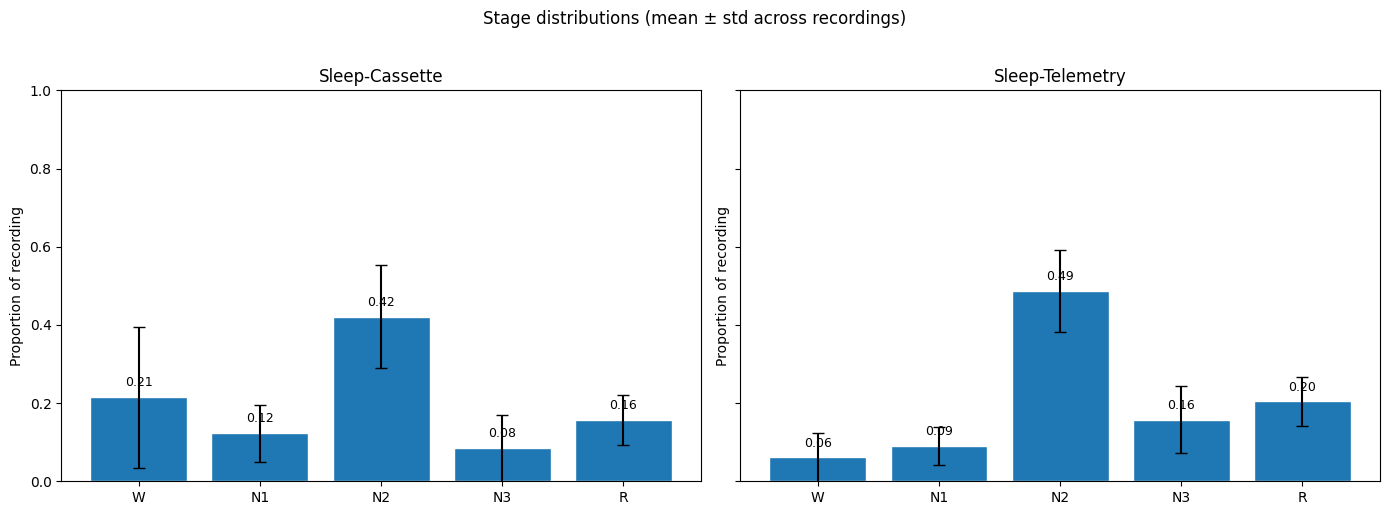

In [ ]:
# stage distribution comparison per dataset
def plot_stage_distributions(df):
    stages = ['W', 'N1', 'N2', 'N3', 'R']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, (name, sub_df) in zip(axes, df.groupby('dataset')):
        # normalise per recording then average
        counts = sub_df[[f'n_{s}' for s in stages]].values
        proportions = counts / counts.sum(axis=1, keepdims=True)
        means = proportions.mean(axis=0)
        stds = proportions.std(axis=0)

        bars = ax.bar(stages, means, yerr=stds,
                      capsize=4, edgecolor='white')
        ax.set_title(name)
        ax.set_ylabel("Proportion of recording")
        ax.set_ylim(0, 1)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02,
                    f'{m:.2f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle("Stage distributions (mean ± std across recordings)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_stage_distributions(df)

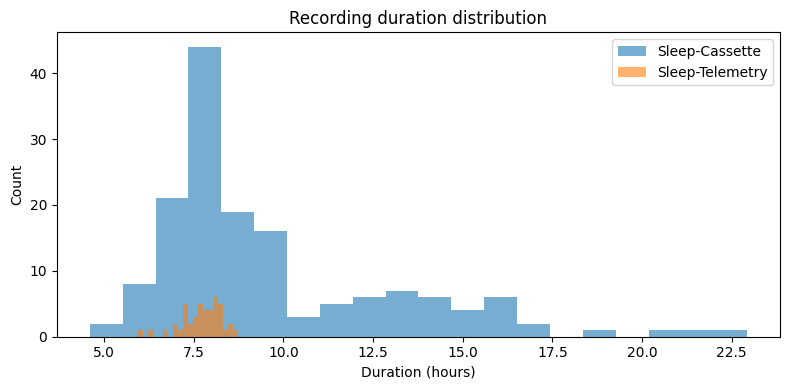

In [ ]:
# recording duration distributions per dataset
def plot_durations(df):
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, sub_df in df.groupby('dataset'):
        ax.hist(sub_df['duration_h'], bins=20, alpha=0.6, label=name)
    ax.set_xlabel("Duration (hours)")
    ax.set_ylabel("Count")
    ax.set_title("Recording duration distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_durations(df)

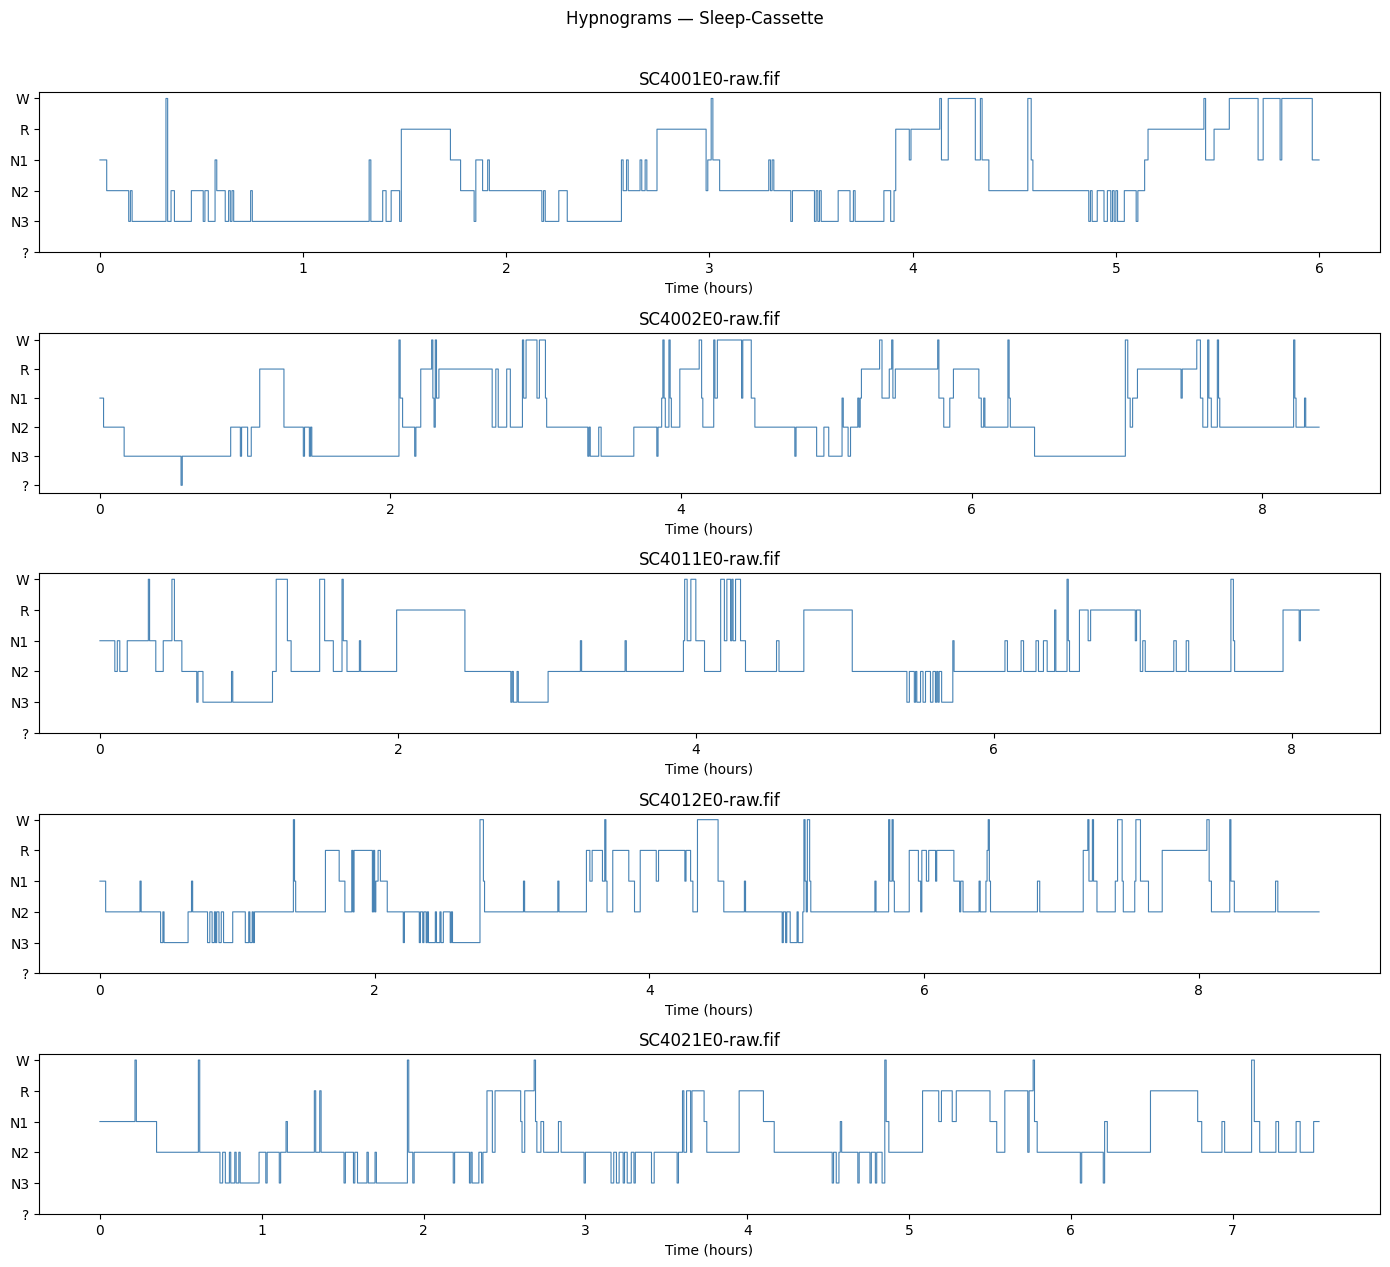

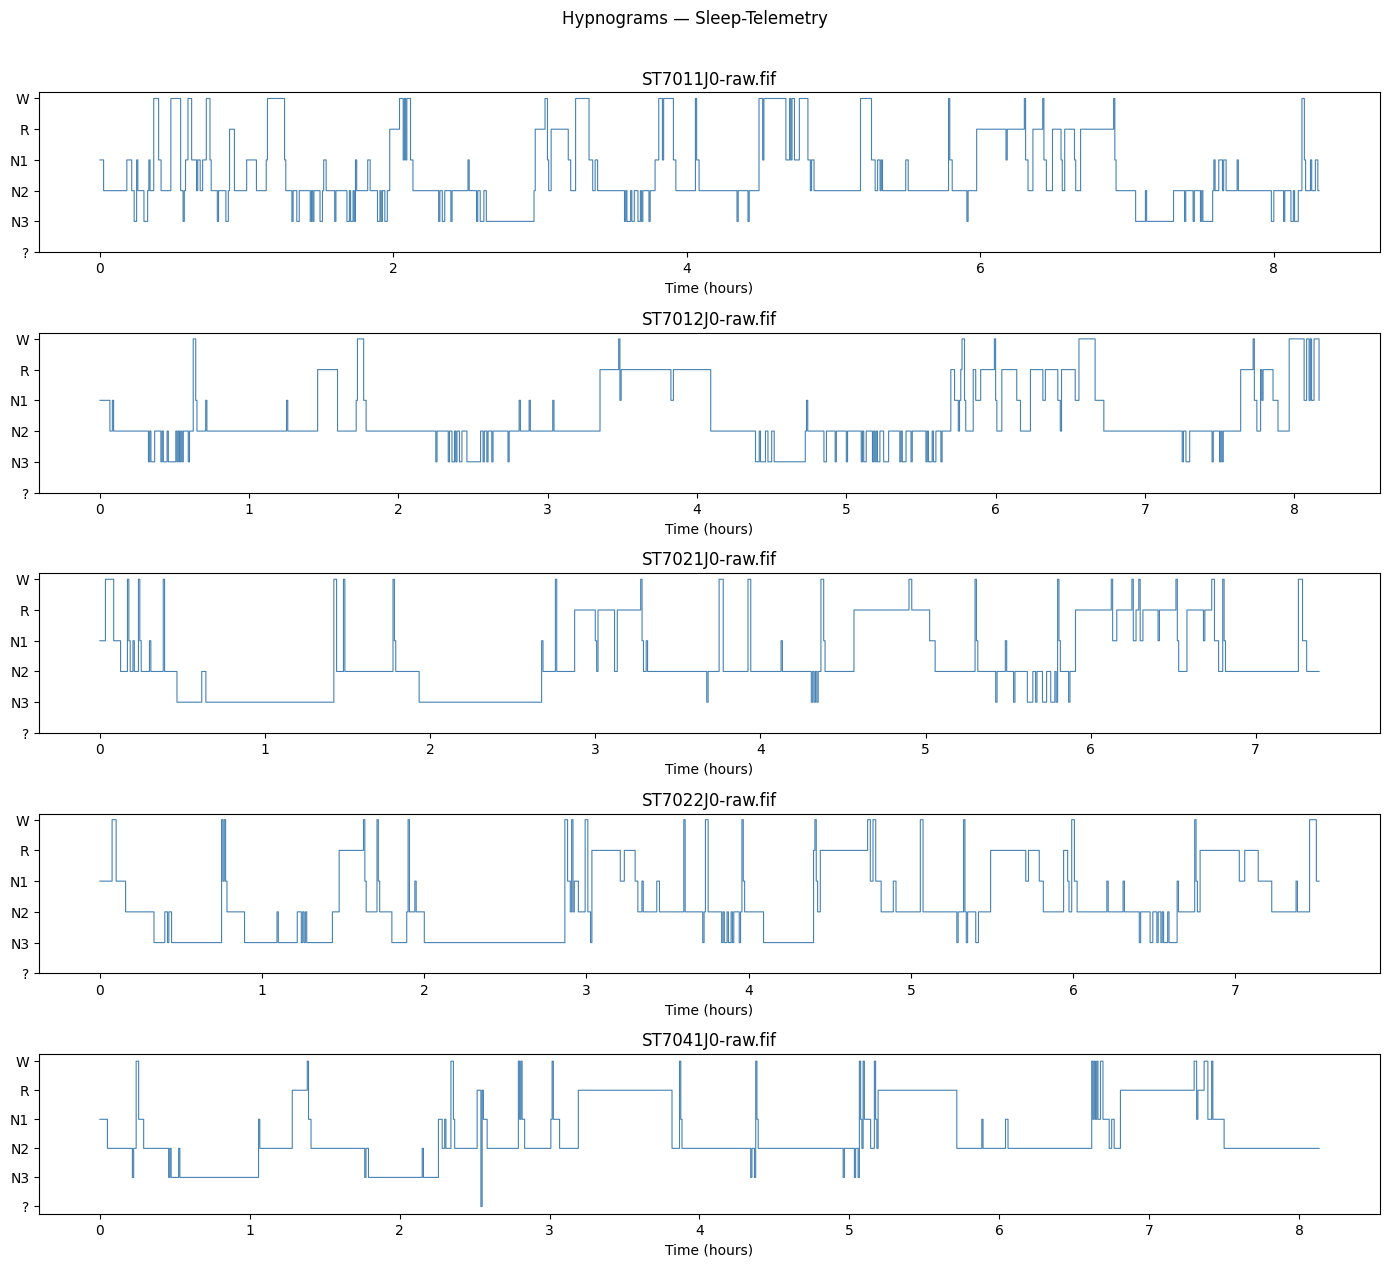

In [ ]:
# plotting example hypnograms of first 5 files -> should start and end with a sleep stage as wake and ? before and after were removed in preprocessing
def plot_hypnograms(paths, name, max_files=5):
    files = paths[:max_files]
    fig, axes = plt.subplots(len(files), 1, figsize=(14, 2.5 * len(files)))
    if len(files) == 1:
        axes = [axes]

    for ax, path in zip(axes, files):
        raw = mne.io.read_raw_fif(path, preload=False, verbose='ERROR')
        annot = raw.annotations

        y = [stage_order[stage_map.get(d, '?')] for d in annot.description]
        x = annot.onset / 3600

        x_step = np.repeat(x, 2)[1:]
        y_step = np.repeat(y, 2)[:-1]

        ax.plot(x_step, y_step, color='steelblue', linewidth=0.8)
        ax.set_yticks(list(stage_order.values()))
        ax.set_yticklabels(list(stage_order.keys()))
        ax.set_xlabel("Time (hours)")
        ax.set_title(path.split('/')[-1])
        ax.invert_yaxis()

    plt.suptitle(f"Hypnograms — {name}", y=1.01)
    plt.tight_layout()
    plt.show()

for name, paths in datasets.items():
    plot_hypnograms(paths, name)

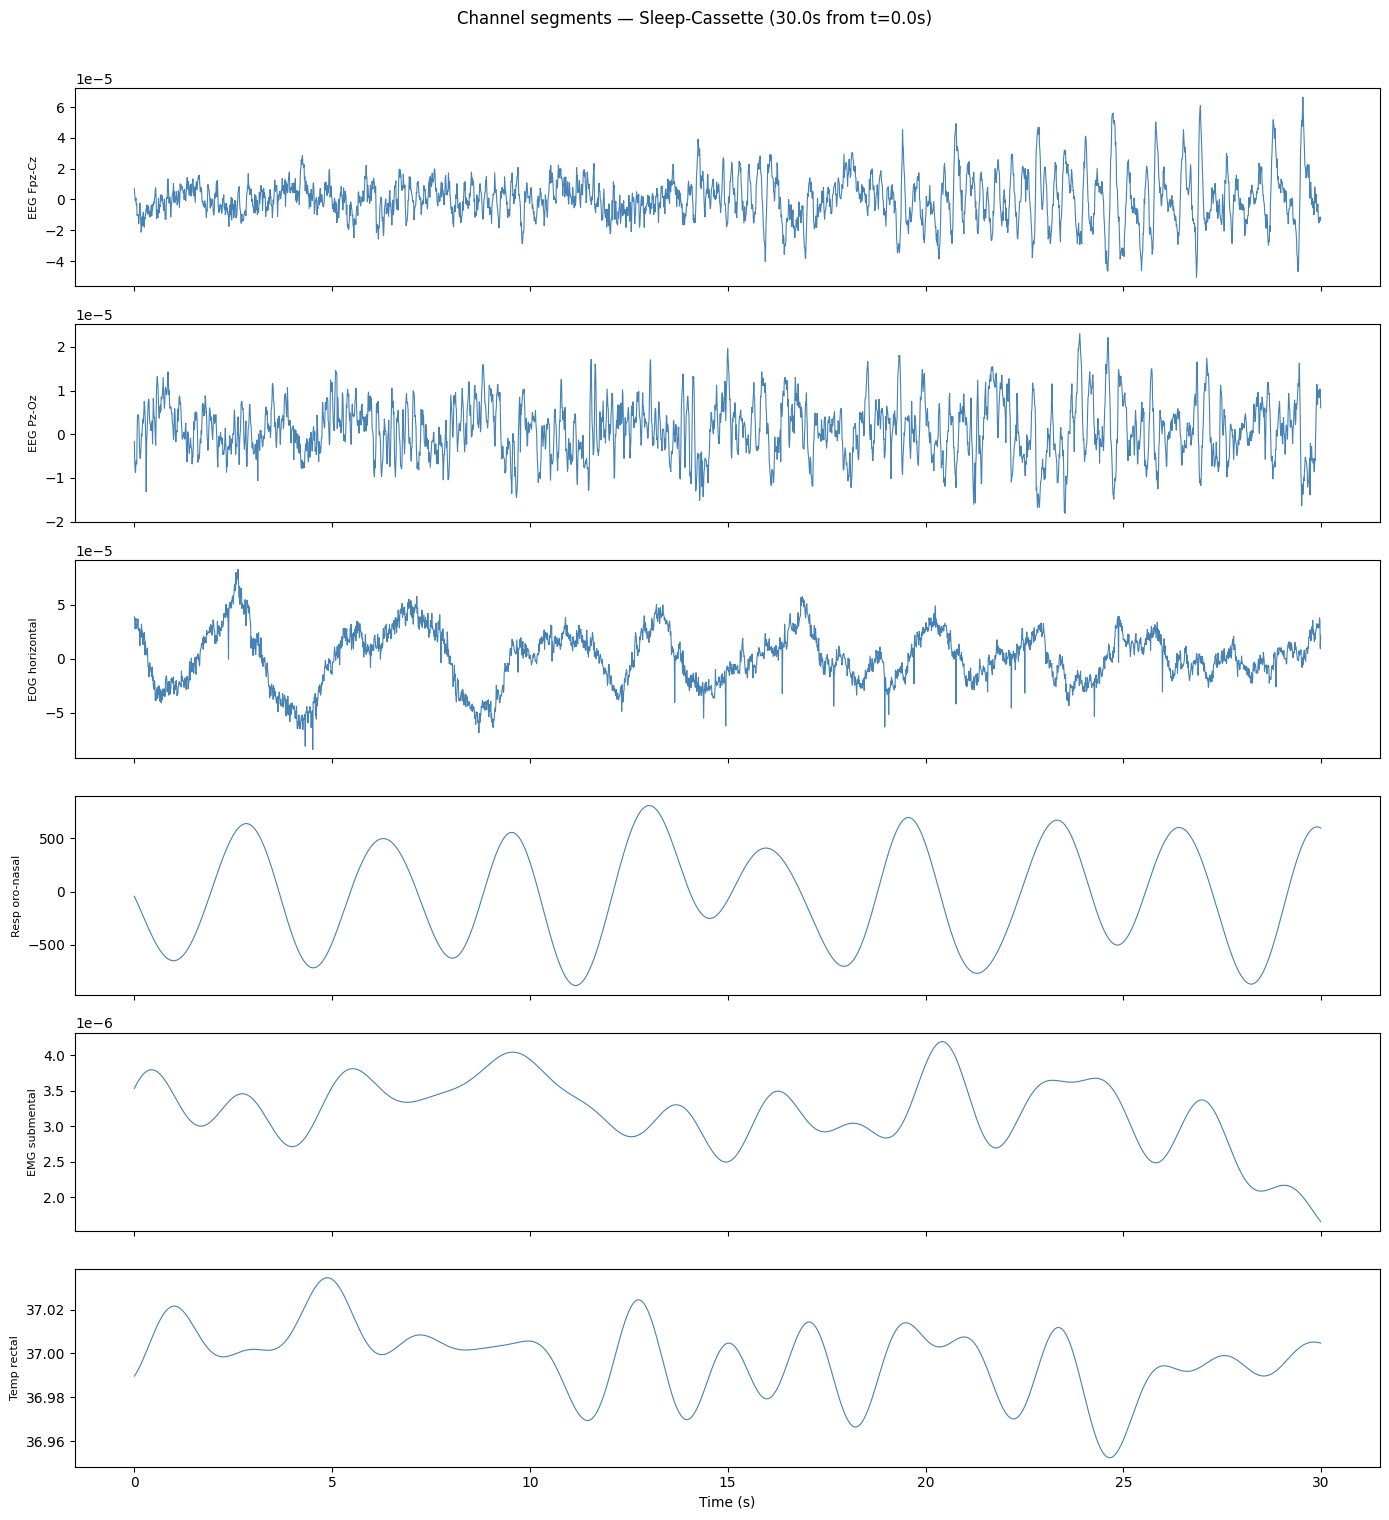

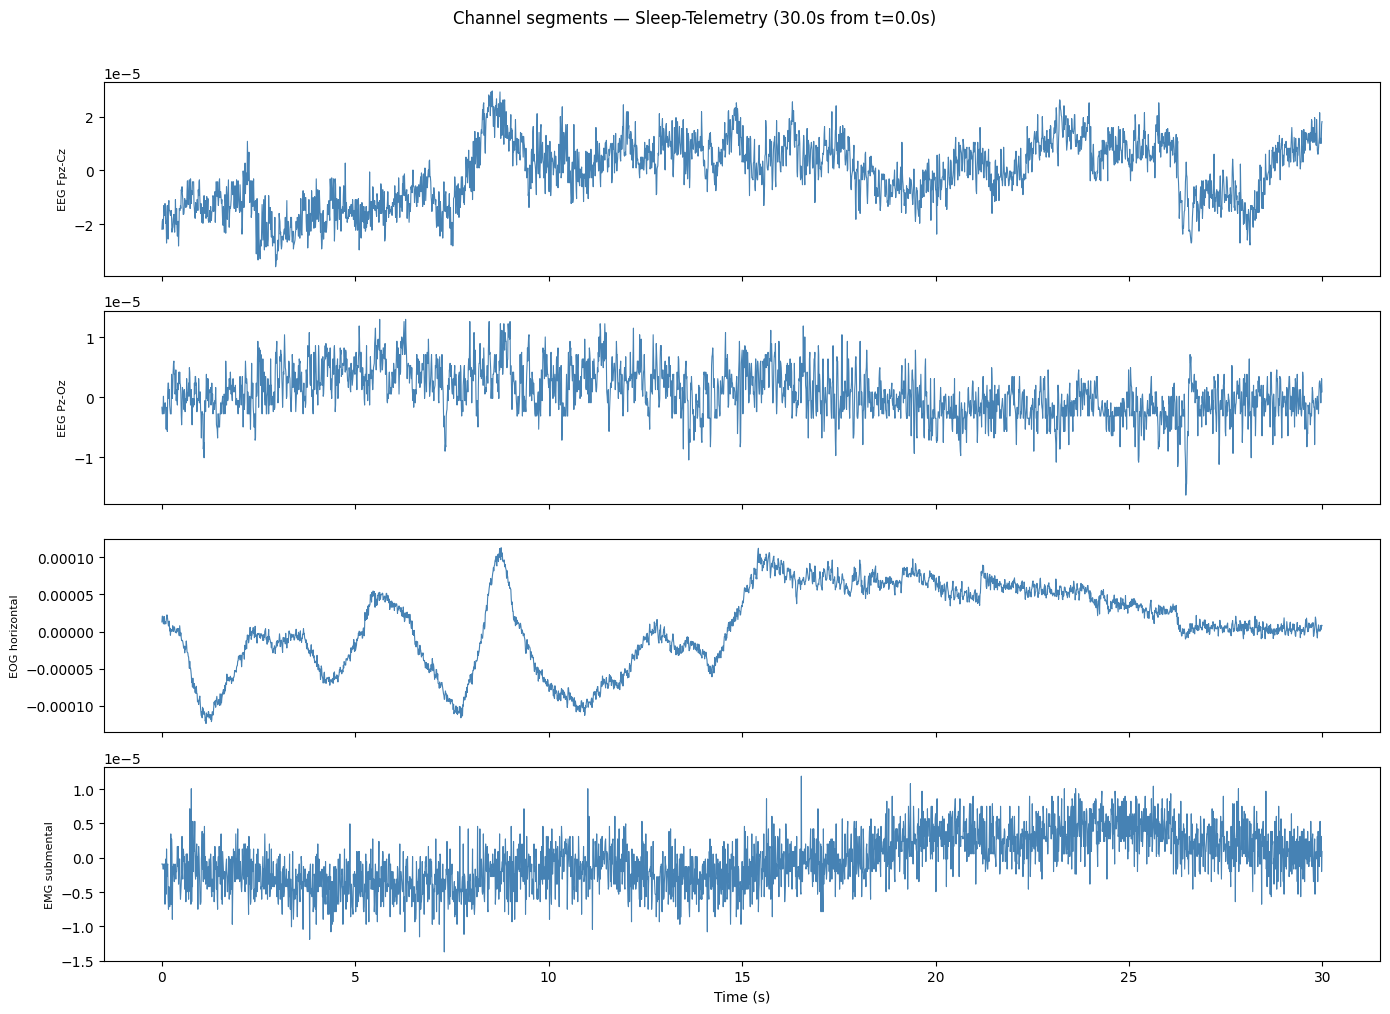

In [ ]:
# plot first epoch of each channel for one file from each dataset (can change number of path to look at different files)

sc_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal']
st_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

channel_map = {"Sleep-Cassette": sc_channels, "Sleep-Telemetry": st_channels}

def plot_channel_segments(paths, name, duration=30.0, start=0.0):
    channels = channel_map[name]
    raw = mne.io.read_raw_fif(paths[0], preload=True, verbose='ERROR')
    sfreq = raw.info['sfreq']

    start_sample = int(start * sfreq)
    end_sample = int((start + duration) * sfreq)

    fig, axes = plt.subplots(len(channels), 1, figsize=(14, 2.5 * len(channels)), sharex=True)

    for ax, ch in zip(axes, channels):
        if ch in raw.ch_names:
            idx = raw.ch_names.index(ch)
            data = raw.get_data([idx]).squeeze()[start_sample:end_sample]
            times = raw.times[start_sample:end_sample]
            ax.plot(times, data, linewidth=0.8, color='steelblue')
            ax.set_ylabel(ch, fontsize=8)
        else:
            ax.text(0.5, 0.5, f'{ch} not found', ha='center', va='center',
                    transform=ax.transAxes, color='grey')

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle(f"Channel segments — {name} ({duration}s from t={start}s)", y=1.01)
    plt.tight_layout()
    plt.show()

for name, paths in datasets.items():
    plot_channel_segments(paths, name)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Effective window size : 20.480 (s)


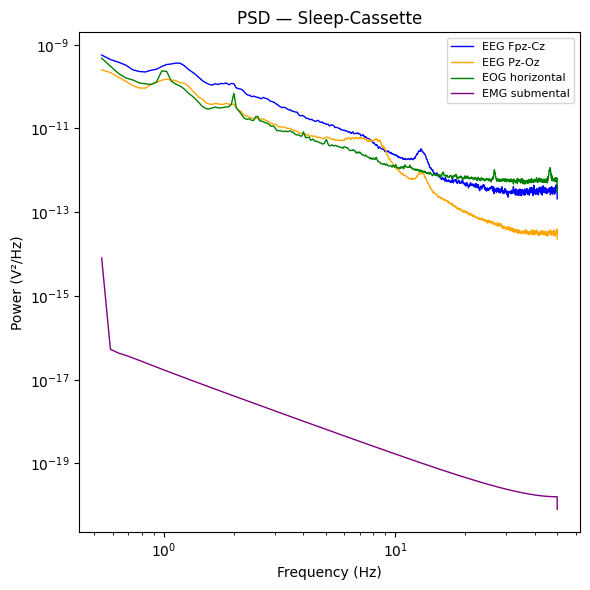

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Effective window size : 20.480 (s)


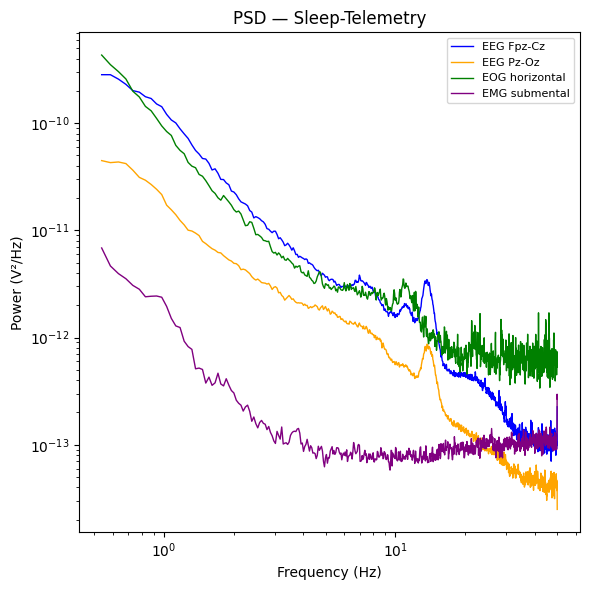

In [ ]:
# plot PSD of each channel for one file from each dataset (can change number of path to look at different files)

channel_colors = {
    'EEG Fpz-Cz':      'blue',
    'EEG Pz-Oz':       'orange',
    'EOG horizontal':  'green',
    'EMG submental':   'purple',
}
eeg_eog_emg = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

def plot_psds(paths, name):
    channels = [ch for ch in channel_map[name] if ch in eeg_eog_emg]
    raw = mne.io.read_raw_fif(paths[1], preload=True, verbose='ERROR')
    available = [ch for ch in channels if ch in raw.ch_names]
    raw.pick_channels(available)

    psd = raw.compute_psd(method='welch', fmin=0.5, fmax=50.0)
    freqs = psd.freqs
    data = psd.get_data()

    fig, ax = plt.subplots(figsize=(6, 6))

    for ch, power in zip(available, data):
        ax.plot(freqs, power, label=ch, color=channel_colors[ch], linewidth=1.0)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (V²/Hz)")
    ax.legend(fontsize=8)
    ax.set_title(f"PSD — {name}")
    plt.tight_layout()
    plt.show()

for name, paths in datasets.items():
    plot_psds(paths, name)